# Importing libraries

In [22]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv("data/data.csv")
df

,Gene_Symbol,rsID,Chromosome,Position,Ref_Allele,Alt_Allele,Variant_Type,Variant_Type_Label,Non_Coding_Region,Non_Coding_Region_Label,...,TF_FOXM1_disrupted,TF_FOXM1_created,TF_FOSL2_disrupted,TF_FOSL2_created,TF_Count_Disrupted,TF_Count_Created,Max_Disruption_Score,Most_Disrupted_TF,Most_Created_TF,Motif_Score_Reliable
0,BRCA1,rs8176320,Chr17,43044346,C,G,0,single nucleotide variant,0,3_prime_UTR,...,0,0,0,0,0,0,0.0,NaN,NaN,1
1,BRCA1,rs12516,Chr17,43044391,G,A,0,single nucleotide variant,0,3_prime_UTR,...,0,0,0,0,0,0,0.0,NaN,NaN,1
2,BRCA1,rs548275991,Chr17,43044392,G,A,0,single nucleotide variant,0,3_prime_UTR,...,0,0,0,0,0,0,0.0,NaN,NaN,1
3,BRCA1,rs8176319,Chr17,43044897,G,A,0,single nucleotide variant,0,3_prime_UTR,...,0,0,0,0,0,0,0.0,NaN,NaN,1
4,BRCA1,rs8176318,Chr17,43045257,C,A,0,single nucleotide variant,0,3_prime_UTR,...,0,0,0,0,0,0,0.0,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2396,CHEK2,rs1033667,Chr22,28734312,C,T,0,single nucleotide variant,2,intronic,...,0,0,0,0,0,0,0.0,NaN,NaN,1
2397,CHEK2,rs3841692,Chr22,28734360,NaN,NaN,1,indel,2,intronic,...,0,0,0,0,0,0,0.0,NaN,NaN,0
2398,CHEK2,rs587780181,Chr22,28734462,NaN,NaN,1,indel,1,5_prime_UTR,...,0,0,0,0,0,0,0.0,NaN,NaN,0
2399,CHEK2,rs2236141,Chr22,28741882,C,T,0,single nucleotide variant,4,upstream,...,0,0,0,0,0,0,0.0,NaN,NaN,1


# Data Exploration, Preprocessing


Note:
Variant_Type: 0=SNV, 1=indel, 2=deletion, 3=insertion, 4=other

Non_Coding_Region: 0=3'UTR, 1=5'UTR, 2=intronic, 3=splice region, 4=upstream, 5=downstream, 6=intergenic, 7=nc transcript, 8=regulatory, 9=other

ClinVar_Significance: -1=missing, 0=benign, 1=likely-benign, 2=uncertain, 3=likely-pathogenic, 4=pathogenic
* using this as label, with just "benign", "likely-benign", "pathogenic","likely-pathogenic"

* Drop unlabelled/uncertain data
* Remove columns with single-valued or null-valued values:

In [3]:
labels_out =  ["uncertain-significance", "not-provided", "conflicting-interpretations-of-pathogenicity"]
data = df.drop(df[df["ClinVar_Significance_Label"].isin(labels_out)].index)
data["ClinVar_Significance_Label"].value_counts()
for col in data.columns: # drop homogeneous columns
    if(len(data[col].value_counts())==1):
        data.drop(col, axis=1, inplace=True)
data.drop("H3K27ac_CellLines",axis=1,inplace=True)

see dataframe column info, validate that the remaining data is what we want


In [4]:
data.info()
for col in data.columns:
    print(f"--------- Value counts for {col}")
    print(data[col].value_counts())
    print(len(data[col].value_counts()))

<class 'pandas.DataFrame'>
Index: 1596 entries, 0 to 2400
Data columns (total 59 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gene_Symbol                 1596 non-null   str    
 1   rsID                        1596 non-null   str    
 2   Chromosome                  1596 non-null   str    
 3   Position                    1596 non-null   int64  
 4   Ref_Allele                  1353 non-null   str    
 5   Alt_Allele                  1353 non-null   str    
 6   Variant_Type                1596 non-null   int64  
 7   Variant_Type_Label          1587 non-null   str    
 8   Non_Coding_Region           1596 non-null   int64  
 9   Non_Coding_Region_Label     1596 non-null   str    
 10  H3K4me3                     1596 non-null   int64  
 11  H3K27ac                     1596 non-null   int64  
 12  Top_TF_Binding              1596 non-null   str    
 13  ClinVar_Significance        1596 non-null   int64

Alternative: Label Benign samples as 0, Pathogenic as 1? compare models...?

In [5]:
def add_clinvar_target_label(x):
    if x=="benign" or x=="benign-likely-benign":
        return 0
    elif x =="likely-benign":
        return 1
    elif x=="likely-pathogenic":
        return 2
    elif x=="pathogenic" or x=="pathogenic-likely-pathogenic":
        return 3


NOTE: skipping  'Sequence_Alt', 'Sequence_Ref' - change this if needed

In [6]:
non_categorical_data = ['Position', 'H3K4me3', 'H3K27ac','GTEx_eQTL',  'Known_Regulatory_Effect' , 'Training_Split',  'H3K4me3_PeakCount', 'H3K4me3_PeakScore', 'H3K27ac_PeakScore','PhyloP_Score', 'TF_MNT_disrupted', 'TF_MNT_created', 'TF_MAX_disrupted', 'TF_MAX_created', 'TF_ELF1_disrupted', 'TF_CREB1_disrupted', 'TF_CREB1_created', 'TF_TOE1_created', 'TF_ELK1_disrupted', 'TF_OVOL1_created', 'TF_ZFX_disrupted', 'TF_ZFX_created', 'TF_FOS_disrupted', 'TF_FOS_created', 'TF_FOXA1_created', 'TF_JUND_disrupted', 'TF_MSX2_created', 'TF_MYC_disrupted', 'TF_GATA3_disrupted', 'TF_GATA3_created', 'TF_NR2F2_disrupted', 'TF_NR2F2_created', 'TF_E4F1_disrupted', 'TF_E4F1_created', 'TF_E2F8_disrupted', 'TF_E2F8_created', 'TF_FOXM1_created', 'TF_FOSL2_disrupted', 'Max_Disruption_Score', 'Motif_Score_Reliable']

In [7]:
encoded_columns=[]
nc_region_label = pd.get_dummies(data["Non_Coding_Region_Label"],prefix="nc_region",dtype=int)
encoded_columns.append(nc_region_label)

encode_gene_symbol = pd.get_dummies(data["Gene_Symbol"],dtype=int)
encoded_columns.append(encode_gene_symbol)

encode_chromosome = pd.get_dummies(data["Chromosome"],dtype=int)
encoded_columns.append(encode_chromosome)

encode_variant_type = pd.get_dummies(data["Variant_Type_Label"],dtype=int) # this ok?
encoded_columns.append(encode_variant_type)

enc_NC_region_label = pd.get_dummies(data["Non_Coding_Region_Label"],dtype=int)
encoded_columns.append(enc_NC_region_label)

enc_Top_TF_Bind = pd.get_dummies(data["Top_TF_Binding"],dtype=int)
encoded_columns.append(enc_Top_TF_Bind)

enc_seq_status = pd.get_dummies(data["Sequence_Status"],dtype=int)
encoded_columns.append(enc_seq_status)

enc_count_dis = pd.get_dummies(data["TF_Count_Disrupted"],dtype=int,prefix="TF_count_disrupt")
encoded_columns.append(enc_count_dis)

enc_tf_count_create = pd.get_dummies(data["TF_Count_Created"],dtype=int,prefix = "TF_Count_Created")
encoded_columns.append(enc_tf_count_create)

enc_tf_most_disrupt = pd.get_dummies(data["Most_Disrupted_TF"],dtype=int)
encoded_columns.append(enc_tf_most_disrupt)

enc_tf_most_create = pd.get_dummies(data["Most_Created_TF"],dtype=int)



Put everything into dataframe model will use. Convert dataframe -> np array

In [8]:
model_data = pd.DataFrame()
model_data = pd.concat(encoded_columns, axis=1)
model_data["target_label"]=data['ClinVar_Significance_Label'].map(add_clinvar_target_label)
model_data = pd.concat([model_data, data[non_categorical_data]], axis=1)
model_data

,nc_region_3_prime_UTR,nc_region_5_prime_UTR,nc_region_intronic,nc_region_nc_transcript,nc_region_splice_region,nc_region_upstream,ATM,BRCA1,BRCA2,CHEK2,...,TF_NR2F2_disrupted,TF_NR2F2_created,TF_E4F1_disrupted,TF_E4F1_created,TF_E2F8_disrupted,TF_E2F8_created,TF_FOXM1_created,TF_FOSL2_disrupted,Max_Disruption_Score,Motif_Score_Reliable
0,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0.0,1
1,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0.0,1
2,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0.0,1
3,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0.0,1
4,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0.0,1
2396,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0.0,1
2397,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0.0,0
2399,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0.0,1


In [9]:
model_data.info()

<class 'pandas.DataFrame'>
Index: 1596 entries, 0 to 2400
Data columns (total 97 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   nc_region_3_prime_UTR                       1596 non-null   int64  
 1   nc_region_5_prime_UTR                       1596 non-null   int64  
 2   nc_region_intronic                          1596 non-null   int64  
 3   nc_region_nc_transcript                     1596 non-null   int64  
 4   nc_region_splice_region                     1596 non-null   int64  
 5   nc_region_upstream                          1596 non-null   int64  
 6   ATM                                         1596 non-null   int64  
 7   BRCA1                                       1596 non-null   int64  
 8   BRCA2                                       1596 non-null   int64  
 9   CHEK2                                       1596 non-null   int64  
 10  PALB2                       

In [13]:
model_data_train = model_data[model_data["Training_Split"] == "Train"]
model_data_train = model_data_train.drop(columns="Training_Split") #remove label column
model_data_test = model_data[model_data["Training_Split"] == "Test"]
model_data_test = model_data_test.drop(columns="Training_Split") # remove label column
#Split X and Y by train/test set
x_data_train = model_data_train.drop(columns="target_label")
y_data_train = model_data_train["target_label"]
x_data_test = model_data_test.drop(columns="target_label")
y_data_test = model_data_test["target_label"]


0       1
1       0
2       1
4       0
7       3
       ..
2389    0
2392    2
2395    3
2396    0
2400    0
Name: target_label, Length: 1117, dtype: int64

Scaling features

In [16]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_data_train)
x_test_scaled = scaler.transform(x_data_test)

In [19]:
svm_model = SVC(kernel='rbf')
svm_model.fit(x_train_scaled, y_data_train)
predictions = svm_model.predict(x_test_scaled)

Overall Accuracy: 0.7458333333333333

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.65      0.21      0.31        53
           1       0.77      0.97      0.86       157
           2       0.55      0.50      0.52        12
           3       0.67      0.56      0.61        18

    accuracy                           0.75       240
   macro avg       0.66      0.56      0.58       240
weighted avg       0.72      0.75      0.70       240

--- Confusion Matrix ---


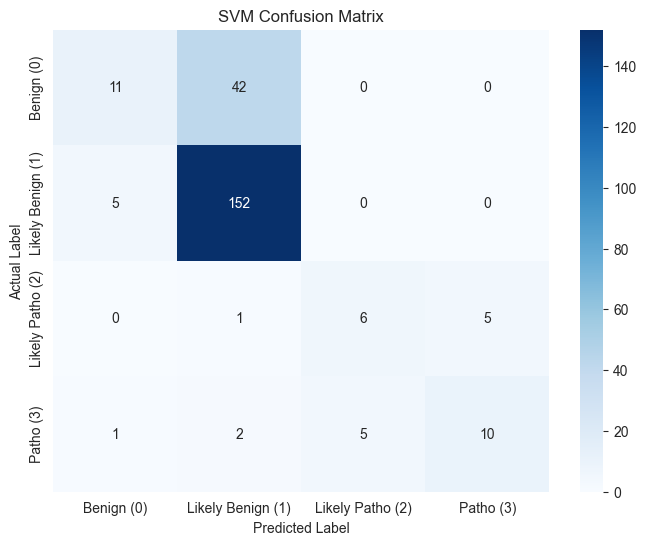

In [23]:
print(f"Overall Accuracy: {accuracy_score(y_data_test, predictions)}\n")
print("--- Classification Report ---")
print(classification_report(y_data_test, predictions))
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_data_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign (0)", "Likely Benign (1)", "Likely Patho (2)", "Patho (3)"],
            yticklabels=["Benign (0)", "Likely Benign (1)", "Likely Patho (2)", "Patho (3)"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('SVM Confusion Matrix')
plt.show()